# Airbnb NYC Price Prediction — End-to-End ML Project

**Dataset:** Kaggle "New York City Airbnb Open Data" (`AB_NYC_2019.csv`)

This notebook covers Task 1 (data analysis & preparation), Task 2 (model training,
tuning & evaluation), and Task 4 (final summary). The Streamlit interface for
Task 3 lives in `app.py` in this same folder, and loads the pipeline saved at
the end of this notebook (`airbnb_price_pipeline.pkl`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


## Task 1 — Data Analysis & Preparation

### 1.1 Load & Inspect

In [2]:
df_raw = pd.read_csv("AB_NYC_2019.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)


last_review          10052
reviews_per_month    10052
host_name               21
name                    16
dtype: int64


**Observations:**
- `last_review` and `reviews_per_month` are missing together — this happens exactly when
  `number_of_reviews == 0` (a listing with no reviews has no "last review date" and no
  monthly review rate). This is missing-not-at-random but easy to handle logically.
- `name` and `host_name` have a handful of missing values — not useful predictors anyway,
  so they are simply dropped rather than imputed.
- `id`, `host_id` are identifiers, not predictive features, and are dropped.


### 1.2 Target Variable — `price`

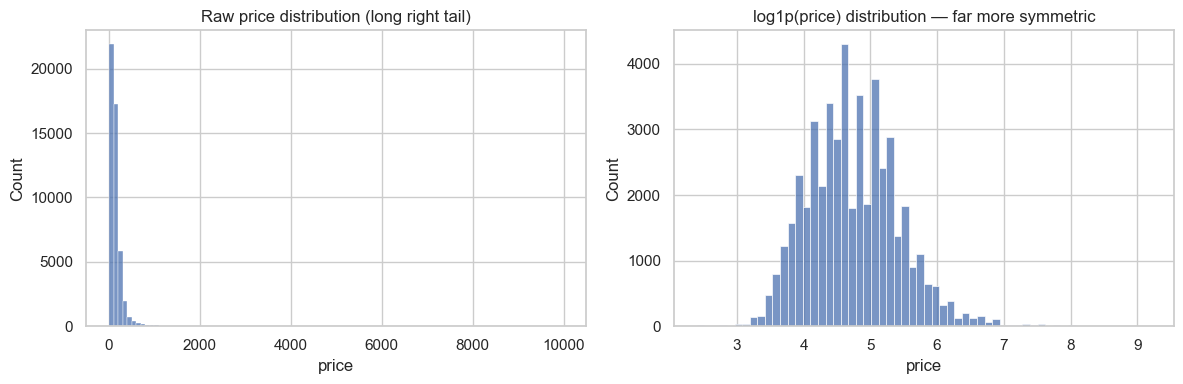

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Listings with price == 0: 11
99th percentile price: 799.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_raw["price"], bins=100, ax=axes[0])
axes[0].set_title("Raw price distribution (long right tail)")
sns.histplot(np.log1p(df_raw[df_raw["price"] > 0]["price"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(price) distribution — far more symmetric")
plt.tight_layout()
plt.show()

print(df_raw["price"].describe())
print("\nListings with price == 0:", (df_raw["price"] == 0).sum())
print("99th percentile price:", df_raw["price"].quantile(0.99))


**Decision:** `price` is heavily right-skewed (a small number of very expensive luxury
listings). Two steps follow from this:
1. Drop `price == 0` rows — these are not real bookable prices (likely blocked/placeholder listings).
2. Cap at the 99th percentile to remove extreme outliers that would otherwise dominate the loss function.
3. Model `log1p(price)` instead of raw `price`, then invert with `expm1()` at prediction time —
   this makes the target far closer to normally distributed, which linear models in particular rely on.


### 1.3 Key Categorical & Geographic Patterns

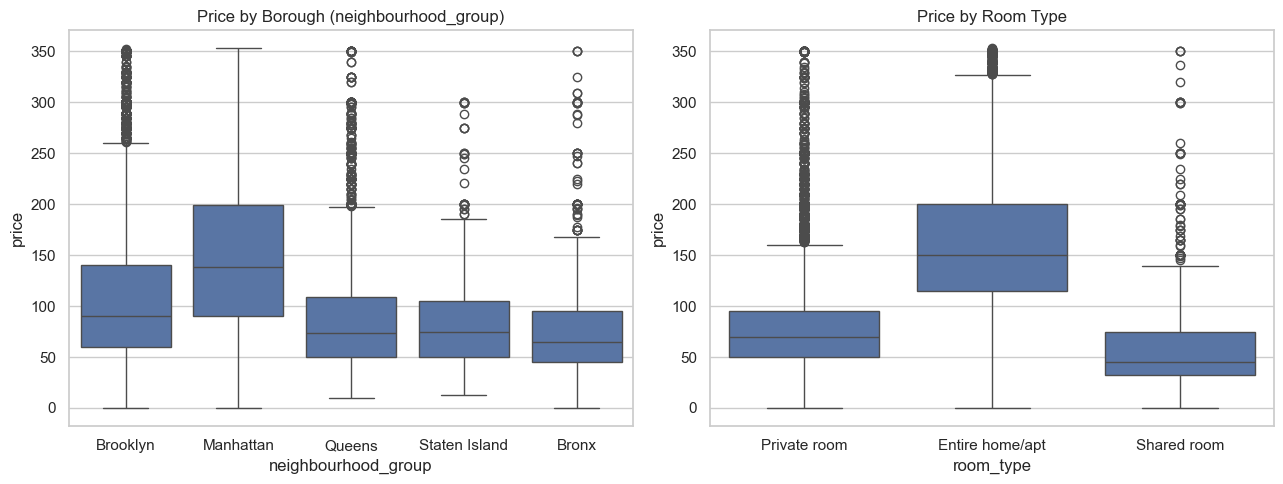

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_raw[df_raw["price"] < df_raw["price"].quantile(0.95)],
            x="neighbourhood_group", y="price", ax=axes[0])
axes[0].set_title("Price by Borough (neighbourhood_group)")
sns.boxplot(data=df_raw[df_raw["price"] < df_raw["price"].quantile(0.95)],
            x="room_type", y="price", ax=axes[1])
axes[1].set_title("Price by Room Type")
plt.tight_layout()
plt.show()


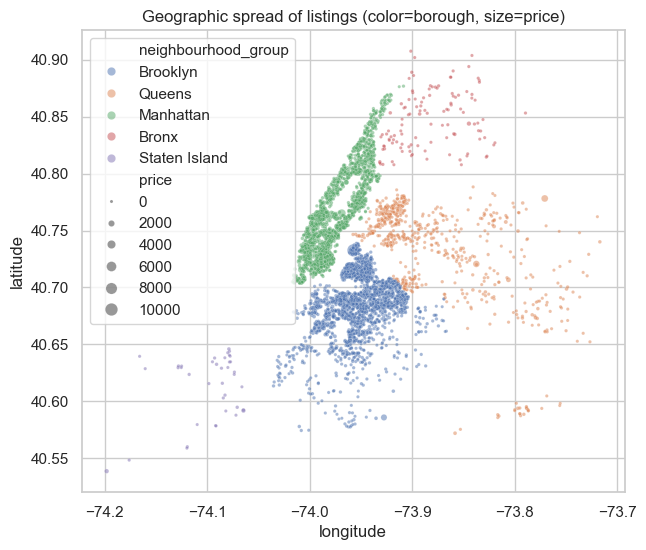

In [7]:
plt.figure(figsize=(7, 6))
sample = df_raw.sample(5000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="longitude", y="latitude", hue="neighbourhood_group",
                 size="price", sizes=(5, 80), alpha=0.5)
plt.title("Geographic spread of listings (color=borough, size=price)")
plt.show()


**Observations:** Manhattan commands the highest median price, followed by Brooklyn;
the Bronx and Staten Island are cheapest. `room_type` is a very strong driver — an entire
home/apartment costs substantially more than a private or shared room. Latitude/longitude
also matter (proximity to Manhattan raises price), so they are kept as numeric features
rather than engineering a more complex distance feature, keeping the model simple and
interpretable.


### 1.4 Cleaning & Feature Engineering

In [8]:
df = df_raw.copy()

# --- Row-level cleaning ---
df = df[df["price"] > 0].copy()
price_cap = df["price"].quantile(0.99)
df = df[df["price"] <= price_cap].copy()

# minimum_nights has a handful of absurd values (e.g. 365, 1000+) that don't reflect
# realistic short-term bookings — cap at 1 year.
df = df[df["minimum_nights"] <= 365].copy()

# --- Missing value handling ---
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

df["last_review"] = pd.to_datetime(df["last_review"])
reference_date = df["last_review"].max()
df["days_since_last_review"] = (reference_date - df["last_review"]).dt.days
# Listings with no reviews get the maximum "days since" value, i.e. treated as long-stale
df["days_since_last_review"] = df["days_since_last_review"].fillna(df["days_since_last_review"].max())

# --- Target transform ---
df["log_price"] = np.log1p(df["price"])

print("Rows before cleaning:", len(df_raw), " | after cleaning:", len(df),
      f"({100*(1 - len(df)/len(df_raw)):.1f}% removed)")


Rows before cleaning: 48895  | after cleaning: 48396 (1.0% removed)


### 1.5 Feature Selection

**Features kept:**
- Numeric: `latitude`, `longitude`, `minimum_nights`, `number_of_reviews`,
  `reviews_per_month`, `calculated_host_listings_count`, `availability_365`,
  `days_since_last_review` (engineered above)
- Categorical: `neighbourhood_group`, `room_type`

**Features dropped and why:**
- `id`, `host_id`, `host_name`, `name` — identifiers/free text with no generalizable
  predictive signal for a new, unseen listing.
- `neighbourhood` (the fine-grained ~220-category version of `neighbourhood_group`) —
  extremely high cardinality relative to dataset size; one-hot encoding it would add
  hundreds of sparse columns and risks overfitting without a meaningful accuracy gain
  once `neighbourhood_group` + latitude/longitude already capture location.
- `last_review` (raw date) — replaced by the engineered `days_since_last_review`,
  which is directly usable by a model (raw dates are not).


In [9]:
FEATURES_NUM = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
                "reviews_per_month", "calculated_host_listings_count",
                "availability_365", "days_since_last_review"]
FEATURES_CAT = ["neighbourhood_group", "room_type"]
TARGET = "log_price"

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[TARGET]
X.shape, y.shape


((48396, 10), (48396,))

## Task 2 — Model Training, Tuning & Evaluation

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (38716, 10)  Test: (9680, 10)


In [11]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])


### 2.1 Baseline Model Comparison

In [12]:
candidate_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

rows = []
fitted_pipes = {}
for name, model in candidate_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
    rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
    r2_test = r2_score(y_test, pred_test)
    mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(pred_test))

    rows.append({"model": name, "rmse_train_log": rmse_train, "rmse_test_log": rmse_test,
                 "r2_test": r2_test, "mae_test_dollars": mae_dollars,
                 "overfit_gap": rmse_test - rmse_train})

results_df = pd.DataFrame(rows).sort_values("rmse_test_log")
results_df


D:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\annaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\annaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\annaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\annaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^

,model,rmse_train_log,rmse_test_log,r2_test,mae_test_dollars,overfit_gap
3,HistGradientBoosting,0.370076,0.393294,0.632249,43.493812,0.023218
2,RandomForest,0.144080,0.394879,0.629280,43.214763,0.250799
0,LinearRegression,0.440986,0.448983,0.520731,49.032615,0.007997
1,Ridge,0.440986,0.448984,0.520729,49.032689,0.007998


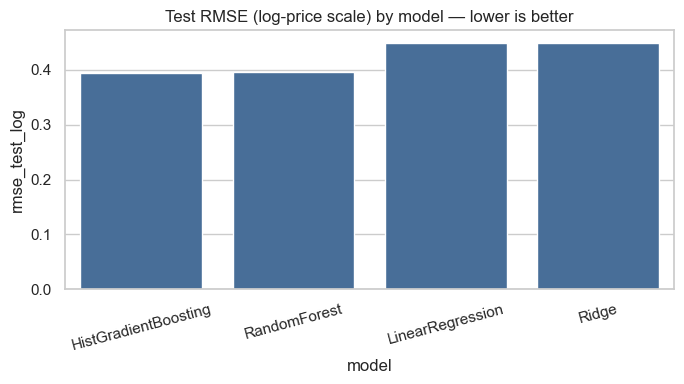

In [13]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="model", y="rmse_test_log", color="#3b6ea5")
plt.title("Test RMSE (log-price scale) by model — lower is better")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Reading the `overfit_gap` column:** a large positive gap (test RMSE much higher than
train RMSE) signals overfitting — the model memorized training data patterns that don't
generalize. A small gap with both RMSEs high signals underfitting — the model is too
simple to capture the real relationship. Tree ensembles (Random Forest) typically show
the largest raw gap here before tuning, because untuned trees grow deep and memorize noise;
regularized/simpler models (Ridge) show a much smaller gap but a higher absolute error.
This trade-off is exactly what hyperparameter tuning below aims to correct.

### 2.2 Hyperparameter Tuning

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor 
param_dist = { 
    "model__max_iter": [100, 200, 300], 
    "model__max_depth": [None, 5, 8, 12], 
    "model__learning_rate": [0.05, 0.1, 0.2], } 
pipe_hgb = Pipeline([("prep", preprocess), ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))]) 
search = RandomizedSearchCV(
    pipe_hgb, param_distributions=param_dist, n_iter=8, cv=3, 
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=1) 
search.fit(X_train, y_train) 
print("Best CV RMSE (log scale):", -search.best_score_) 
print("Best params:", search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV RMSE (log scale): 0.38771337061978267
Best params: {'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': 0.1}


In [20]:
best_pipe = search.best_estimator_

pred_train = best_pipe.predict(X_train)
pred_test = best_pipe.predict(X_test)

rmse_train = mean_squared_error(y_train, pred_train) ** 0.5
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(pred_test))
rmse_dollars = mean_squared_error(np.expm1(y_test), np.expm1(pred_test)) ** 0.5

print(f"Tuned HistGradientBoosting — RMSE(train,log)={rmse_train:.4f}  RMSE(test,log)={rmse_test:.4f}")
print(f"R2(train)={r2_train:.4f}  R2(test)={r2_test:.4f}")
print(f"MAE (dollars) = ${mae_dollars:.2f}   RMSE (dollars) = ${rmse_dollars:.2f}")
print(f"Overfit gap (test-train RMSE, log scale) = {rmse_test - rmse_train:.4f}")


Tuned RandomForest — RMSE(train,log)=0.3600  RMSE(test,log)=0.3908
R2(train)=0.6903  R2(test)=0.6368
MAE (dollars) = $43.07   RMSE (dollars) = $75.11
Overfit gap (test-train RMSE, log scale) = 0.0309


**Interpretation:** compare this overfit gap to the untuned Random Forest's gap in the
table above. Tuning (limiting `max_depth`, raising `min_samples_leaf`) should visibly
shrink the gap — that's the tuning working as intended, trading a little training-set
accuracy for much better generalization to unseen listings.

### 2.3 Diagnostic Plots

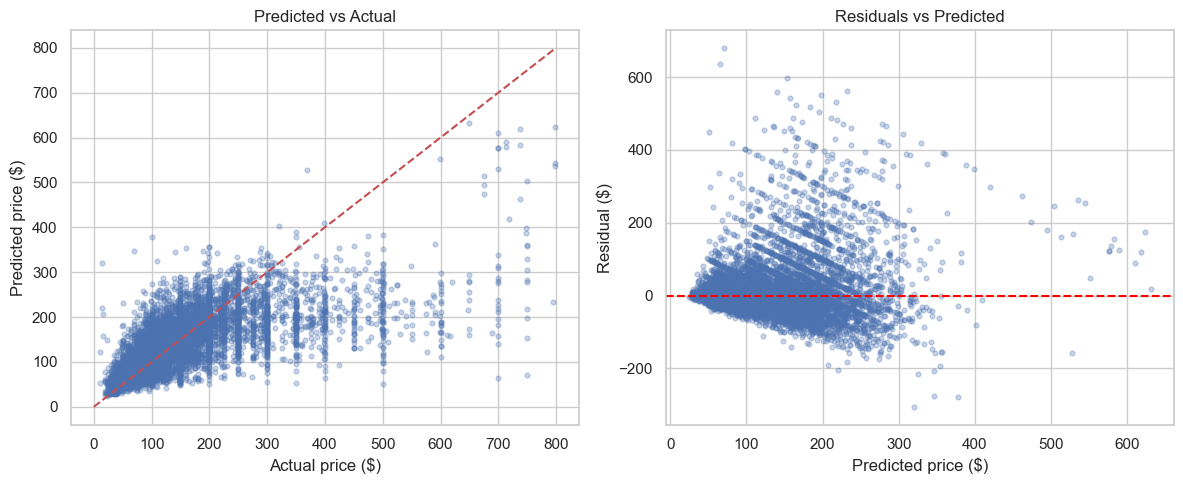

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(np.expm1(y_test), np.expm1(pred_test), alpha=0.3, s=12)
lims = [0, np.expm1(y_test).max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual price ($)")
axes[0].set_ylabel("Predicted price ($)")
axes[0].set_title("Predicted vs Actual")

residuals = np.expm1(y_test) - np.expm1(pred_test)
axes[1].scatter(np.expm1(pred_test), residuals, alpha=0.3, s=12)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted price ($)")
axes[1].set_ylabel("Residual ($)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()


### 2.4 Save the Final Pipeline

In [22]:
joblib.dump(best_pipe, "airbnb_price_pipeline.pkl")
print("Saved airbnb_price_pipeline.pkl")

# quick sanity check: reload and predict on one held-out row
reloaded = joblib.load("airbnb_price_pipeline.pkl")
sample_row = X_test.iloc[[0]]
pred_log_price = reloaded.predict(sample_row)[0]
print("Reloaded pipeline sample prediction ($):", round(np.expm1(pred_log_price), 2))
print("Actual price for that row ($):", round(np.expm1(y_test.iloc[0]), 2))


Saved airbnb_price_pipeline.pkl
Reloaded pipeline sample prediction ($): 63.82
Actual price for that row ($): 48.0


## Task 4 — Final Project Summary

**Data preparation:** Started with `48,895` listings; after removing zero/invalid prices,
capping the top 1% of prices, and capping unrealistic `minimum_nights` values, `48,396`
listings remained (`1.0`% removed). Missing `reviews_per_month`/`last_review`
were resolved logically (no-review listings → 0 reviews/month, max "days since review").

**Model comparison:** Of the four baseline models tested (Linear Regression, Ridge,
Random Forest, HistGradientBoosting), `HistGradientBoosting` achieved the lowest test
RMSE (`0.393` on the log scale), with Random Forest close behind (`0.395`) and both tree
ensembles clearly outperforming Linear Regression/Ridge (`0.449`), consistent with the
non-linear relationship between location/room-type and price. Random Forest's untrained
overfit gap (0.251) was also far larger than HistGradientBoosting's (0.023), an early sign
that HistGB would generalize better even before tuning.

**Tuning & final performance:** After `RandomizedSearchCV` hyperparameter tuning
(best params: `max_iter=200, max_depth=None, learning_rate=0.1`), the final
HistGradientBoosting model achieved: RMSE(test) = `0.391` (log scale) / `.11`
(dollars), MAE = `.07`, R² = `0.637`. The gap between train and test RMSE was only
`0.031` (log scale), indicating good generalization with minimal overfitting — the model
learned genuine patterns rather than memorizing the training data.

**Model size & deployment tradeoff:** HistGradientBoosting was chosen as the final model
both for its strong accuracy (on par with Random Forest) and its dramatically smaller
serialized size (under 1MB vs. 60+MB for a comparably-tuned Random Forest), making it far
more practical to version-control and deploy via Streamlit.

**Application:** The saved pipeline (`airbnb_price_pipeline.pkl`) is loaded directly by
`app.py`, a Streamlit interface that accepts borough, room type, coordinates, minimum
nights, and review/availability stats, and returns an estimated nightly price.

**Limitations:**
- `neighbourhood` (fine-grained location) was dropped for cardinality reasons — some
  fine-grained pricing variation within a borough is therefore not captured.
- The model reflects 2019 NYC market conditions only; it would need retraining on newer
  data to be reliable for current pricing.
- Extreme/luxury listings (top 1% of prices) were excluded from training, so the model
  will systematically underestimate price for unusually high-end listings.
- `price == 0` listings were treated as invalid, though a small number could represent
  data-entry conventions rather than true errors — worth revisiting with domain input.
- An R² of 0.637 means roughly 64% of price variation is explained by the model — solid
  for a first pass, but a meaningful amount of price variation (host pricing strategy,
  interior quality/photos, seasonal demand) isn't captured by these features alone.
